In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('Wine dataset.csv',usecols=[0,1,2])
df.columns = ['class label', 'Alcohol','Malic acid']

In [12]:
df.shape

(178, 3)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class label  178 non-null    int64  
 1   Alcohol      178 non-null    float64
 2   Malic acid   178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


In [15]:
df.sample(5)

,class label,Alcohol,Malic acid
124,2,11.87,4.31
46,1,14.38,3.59
71,2,13.86,1.51
21,1,12.93,3.80
169,3,13.40,4.60


In [14]:
from sklearn.model_selection import train_test_split

In [23]:
x_train , x_test , y_train , y_test = train_test_split(df.drop('class label',axis = 1),df['class label']
                                                       ,test_size=0.3,random_state=0)

In [25]:
y_test.shape

(54,)

In [26]:
from sklearn.preprocessing import MinMaxScaler

In [27]:
scaler = MinMaxScaler()
scaler.fit(x_train)
scaler.fit(x_test)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [32]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [34]:
np.round(x_train.describe())

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.0
std,1.0,1.0
min,11.0,1.0
25%,12.0,2.0
50%,13.0,2.0
75%,14.0,3.0
max,15.0,6.0


In [35]:
np.round(x_train_scaled.describe())

,Alcohol,Malic acid
count,124.0,124.0
mean,0.0,0.0
std,0.0,0.0
min,-0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,1.0,0.0
max,1.0,1.0


Text(0.5, 1.0, 'After Scaling')

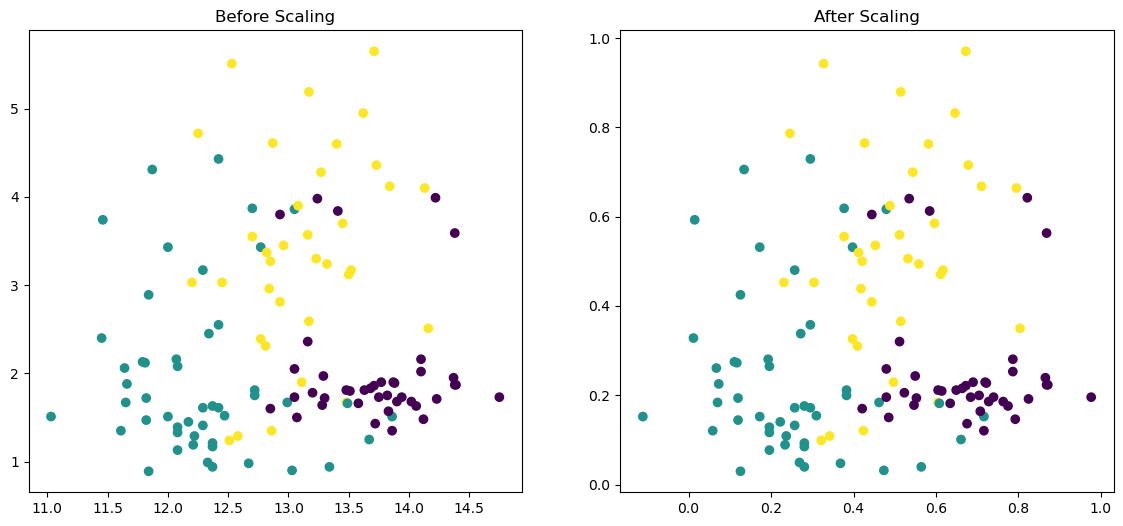

In [42]:
fig , (ax1 , ax2) = plt.subplots(ncols=2 , figsize = (14,6))
ax1.scatter(x_train['Alcohol'],x_train['Malic acid'], c = y_train)
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['Alcohol'],x_train_scaled['Malic acid'],c=y_train)
ax2.set_title('After Scaling')